In [17]:
combinedwkbk23 = read.csv('tippecanoe/Combined_Workbook_2023.csv')
combinedwkbk24 = read.csv('tippecanoe/Combined_Workbook_2024.csv')
combinedexc23 = read.csv('tippecanoe/Combined_Reconciliation_2023.csv')
combinedexc24 = read.csv('tippecanoe/Combined_Reconciliation_2024.csv')
combinedrat23 = read.csv('tippecanoe/Combined_Study_2023.csv')
combinedrat24 = read.csv('tippecanoe/Combined_Study_2024.csv')
added23 = read.csv('tippecanoe/Added_Sales_2023.csv')
added24 = read.csv('tippecanoe/Added_Sales_2024.csv')

In [18]:
library(dplyr)

In [19]:
## For each county, find the % of overall sales in that county that were excluded
combinedexc23 = rbind(combinedexc23,combinedexc24[combinedexc24$County == 'Whitley',])
combinedrat23 = rbind(combinedrat23,combinedrat24[combinedrat24$County == 'Whitley',])
combinedwkbk23 = rbind(combinedwkbk23,combinedwkbk24[combinedwkbk24$County == 'Whitley',])
combinedexc23 = combinedexc23[,c(1,2,3,4,5,6,7,8,9,10,11)]
combinedrat23 = combinedrat23[,c(1,2,3,4,5,6,7,8,9,10,11)]

all_sales <- bind_rows(
  combinedrat23 %>% mutate(Status = "Included"),
  combinedexc23 %>% mutate(Status = "Excluded")
)

exclusion_summary <- all_sales %>%
  group_by(County) %>%
  summarise(
    TotalSales = n(),
    ExcludedSales = sum(Status == "Excluded"),
    PctExcluded = round(100 * ExcludedSales / TotalSales, 2)
  ) %>%
  arrange(desc(PctExcluded))

print(paste('Statewide % of Sales Excluded:',round(nrow(combinedexc23) / (nrow(combinedexc23) + nrow(combinedrat23)) * 100,2),'%'))
exclusion_summary

[1] "Statewide % of Sales Excluded: 44.6 %"


County,TotalSales,ExcludedSales,PctExcluded
<chr>,<int>,<int>,<dbl>
Lawrence,1991,1582,79.46
Rush,359,279,77.72
Madison,3289,2547,77.44
Orange,812,621,76.48
Greene,1200,913,76.08
Sullivan,772,585,75.78
Henry,2137,1607,75.20
Martin,354,266,75.14
Pike,476,342,71.85


In [20]:
## Finds what % of the Property Classes in the 2023 Sales Reconciliation files
## don't match the property classes in the 2023 County Workbook

results <- data.frame(
  County = character(),
  NumExcludedSales = integer(),
  PercentNotMatching = numeric(),
  stringsAsFactors = FALSE
)

total_mismatches <- 0
total_sales <- 0

## Loops over counties to calculate mismatches
for (county in unique(combinedexc23$County)) {
  ctywkbk <- combinedwkbk23[combinedwkbk23$County == county, ]
  ctyexc <- combinedexc23[combinedexc23$County == county, ]

  ## Matches parcels between sales rec file and workbook file
  excluded_indices <- match(ctyexc$ParcelNumber, ctywkbk$ParcelNumber)
  matched <- !is.na(excluded_indices)

  ## Finds # of mismatched property classes
  mismatches <- ctyexc$PropertyClass[matched] != ctywkbk$CurrentPropertyClass[excluded_indices[matched]]
  
  num_mismatches <- sum(mismatches, na.rm = TRUE)
  num_sales <- nrow(ctyexc)
  percent_mismatch <- if (num_sales > 0) round((num_mismatches / num_sales) * 100, 2) else NA
  total_mismatches <- total_mismatches + num_mismatches
  total_sales <- total_sales + num_sales
    
  results <- rbind(
    results,
    data.frame(
      County = county,
      NumExcludedSales = num_sales,
      PercentNotMatching = percent_mismatch
    )
  )
}
print(paste('Statewide % of Incorrect Property Classes (Excluded Sales):',round(total_mismatches / total_sales * 100,2),'%'))
results = results[order(-results$PercentNotMatching),]
print(results)

[1] "Statewide % of Incorrect Property Classes: 6.81 %"
        County NumExcludedSales PercentNotMatching
29    Hamilton             1631              32.80
6        Boone              406              22.41
8      Carroll              331              18.73
17      Dekalb              405              18.02
71       Scott              716              17.60
92     Whitley              602              16.61
25      Fulton              237              15.19
10       Clark             4134              15.09
45        Lake             5961              14.61
13    Crawford              167              12.57
88  Washington              580              12.41
15    Dearborn              607              12.03
66     Pulaski              207              11.59
2        Allen             2966              11.26
65       Posey               98              11.22
90       Wells              439              11.16
31    Harrison              739              10.69
7        Brown            

In [21]:
## Finds what % of the Property Classes in the 2023 Ratio Study files
## don't match the property classes in the 2023 County Workbook

results <- data.frame(
  County = character(),
  NumIncludedSales = integer(),
  PercentNotMatching = numeric(),
  stringsAsFactors = FALSE
)

total_mismatches <- 0
total_sales <- 0

## Loops over counties to calculate mismatches
for (county in unique(combinedrat23$County)) {
  ctywkbk <- combinedwkbk23[combinedwkbk23$County == county, ]
  ctyexc <- combinedrat23[combinedrat23$County == county, ]

  ## Matches parcels between ratio study file and workbook file
  excluded_indices <- match(ctyexc$ParcelNumber, ctywkbk$ParcelNumber)
  matched <- !is.na(excluded_indices)

  ## Finds # of mismatched property classes
  mismatches <- ctyexc$PropertyClass[matched] != ctywkbk$CurrentPropertyClass[excluded_indices[matched]]
  
  num_mismatches <- sum(mismatches, na.rm = TRUE)
  num_sales <- nrow(ctyexc)
  percent_mismatch <- if (num_sales > 0) round((num_mismatches / num_sales) * 100, 2) else NA
  total_mismatches <- total_mismatches + num_mismatches
  total_sales <- total_sales + num_sales
    
  results <- rbind(
    results,
    data.frame(
      County = county,
      NumIncludedSales = num_sales,
      PercentNotMatching = percent_mismatch
    )
  )
}
print(paste('Statewide % of Incorrect Property Classes (Included Sales):',round(total_mismatches / total_sales * 100,2),'%'))
results = results[order(-results$PercentNotMatching),]
print(results)

[1] "Statewide % of Incorrect Property Classes (Included Sales): 1 %"
        County NumIncludedSales PercentNotMatching
8      Carroll              981              27.22
17      Dekalb              674              19.44
76     Steuben              438              18.04
86      Warren              253              12.25
66     Pulaski              394              10.41
16     Decatur              888               8.22
25      Fulton              739               8.12
56      Newton              792               7.45
44    Lagrange              717               7.39
87     Warrick             1424               7.16
38         Jay              442               6.79
11        Clay              355               6.20
24    Franklin              150               6.00
75      Starke              834               6.00
67      Putnam              398               5.78
9         Cass             1140               5.53
58        Ohio              282               5.32
79  Tippecan

In [22]:
## Finds what % of the AV in the 2023 Sales Reconciliation files
## don't match the AV in the 2023 County Workbook
## and how this affects the median ratio of those sales
results_av <- data.frame(
  County = character(),
  NumExcludedSales = integer(),
  PercentNotMatching = numeric(),
  MedianRatioPercentChange = numeric(),
  stringsAsFactors = FALSE
)

## Loops over counties to find mismatches
for (county in unique(combinedexc23$County)) {

  ctywkbk <- combinedwkbk23[combinedwkbk23$County == county, ]
  ctyexc <- combinedexc23[combinedexc23$County == county, ]

  ## Matches parcels between sales rec file and workbook file
  excluded_indices <- match(ctyexc$ParcelNumber, ctywkbk$ParcelNumber)
  matched <- !is.na(excluded_indices)
  matched_indices <- excluded_indices[matched]

  ## Number of excluded sales
  num_sales <- nrow(ctyexc)

  ## Percent mismatch in AV
  av_mismatches <- ctyexc$PostedAV[matched] != ctywkbk$CurrentAV[matched_indices]
  percent_mismatch <- if (num_sales > 0) round((sum(av_mismatches, na.rm = TRUE) / num_sales) * 100, 2) else NA

  ## Default median change as NA
  median_change <- NA

  ## Compute change in median if any AV mismatches exist
  if (sum(av_mismatches, na.rm = TRUE) > 0) {
    ex_old_med <- median(ctyexc$PostedSaleRatio, na.rm = TRUE)
    ex_new_med <- median(ctyexc$SaleRatio, na.rm = TRUE)
    if (!is.na(ex_old_med) && ex_old_med != 0) {
      median_change <- round((ex_new_med - ex_old_med) / ex_old_med * 100, 2)
    }
  }

  results_av <- rbind(
    results_av,
    data.frame(
      County = county,
      NumExcludedSales = num_sales,
      PercentNotMatching = percent_mismatch,
      MedianRatioPercentChange = median_change
    )
  )
}

results_av <- results_av[order(-results_av$MedianRatioPercentChange), ]
print(results_av)

        County NumExcludedSales PercentNotMatching MedianRatioPercentChange
29    Hamilton             1631              89.64                    86.40
45        Lake             5961              93.69                    68.39
6        Boone              406              70.94                    67.90
17      Dekalb              405              93.33                    67.23
58        Ohio               40              97.50                    46.40
10       Clark             4134              94.44                    41.56
47    Lawrence             1582              98.86                    40.65
33       Henry             1607              95.77                    40.59
37      Jasper              317              90.22                    38.46
65       Posey               98              95.92                    38.14
31    Harrison              739              94.45                    35.65
92     Whitley              602              97.18                    34.74
50    Marsha

In [23]:
## Finds what % of the AV in the 2023 Ratio Study files
## don't match the AV in the 2023 County Workbook
## and how this affects the median ratio of those sales
results_av <- data.frame(
  County = character(),
  NumIncludedSales = integer(),
  PercentNotMatching = numeric(),
  MedianRatioPercentChange = numeric(),
  stringsAsFactors = FALSE
)

## Loops over counties to find mismatches
for (county in unique(combinedexc23$County)) {

  ctywkbk <- combinedwkbk23[combinedwkbk23$County == county, ]
  ctyexc <- combinedrat23[combinedrat23$County == county, ]

  ## Matches parcels between ratio study file and workbook file
  excluded_indices <- match(ctyexc$ParcelNumber, ctywkbk$ParcelNumber)
  matched <- !is.na(excluded_indices)
  matched_indices <- excluded_indices[matched]

  ## Number of included sales
  num_sales <- nrow(ctyexc)

  ## Percent mismatch in AV
  av_mismatches <- ctyexc$PostedAV[matched] != ctywkbk$CurrentAV[matched_indices]
  percent_mismatch <- if (num_sales > 0) round((sum(av_mismatches, na.rm = TRUE) / num_sales) * 100, 2) else NA

  ## Default median change as NA
  median_change <- NA

  ## Compute change in median if any AV mismatches exist
  if (sum(av_mismatches, na.rm = TRUE) > 0) {
    ex_old_med <- median(ctyexc$PostedSaleRatio, na.rm = TRUE)
    ex_new_med <- median(ctyexc$SaleRatio, na.rm = TRUE)
    if (!is.na(ex_old_med) && ex_old_med != 0) {
      median_change <- round((ex_new_med - ex_old_med) / ex_old_med * 100, 2)
    }
  }

  results_av <- rbind(
    results_av,
    data.frame(
      County = county,
      NumIncludedSales = num_sales,
      PercentNotMatching = percent_mismatch,
      MedianRatioPercentChange = median_change
    )
  )
}

results_av <- results_av[order(-results_av$MedianRatioPercentChange), ]
print(results_av)

        County NumIncludedSales PercentNotMatching MedianRatioPercentChange
56      Newton              792              12.88                     0.85
76     Steuben              438              20.32                     0.70
58        Ohio              282               8.87                     0.67
8      Carroll              981              33.03                     0.65
87     Warrick             1424              14.61                     0.62
37      Jasper             1150               9.39                     0.61
62       Perry              177              12.43                     0.56
79  Tippecanoe             3138               5.96                     0.53
36     Jackson              675               4.30                     0.37
17      Dekalb              674              22.26                     0.32
2        Allen             6306               3.25                     0.27
16     Decatur              888              10.47                     0.21
71       Sco

In [24]:
## Finds what % of the AV in the 2024 Sales Reconciliation files
## don't match the AV in the 2024 County Workbook
## and how this affects the median ratio of those sales
results_av <- data.frame(
  County = character(),
  NumExcludedSales = integer(),
  PercentNotMatching = numeric(),
  MedianRatioPercentChange = numeric(),
  stringsAsFactors = FALSE
)

## Loops over counties to find mismatches
for (county in unique(combinedexc24$County)) {

  ctywkbk <- combinedwkbk24[combinedwkbk24$County == county, ]
  ctyexc <- combinedexc24[combinedexc24$County == county, ]

  ## Matches parcels between sales rec file and workbook file
  excluded_indices <- match(ctyexc$ParcelNumber, ctywkbk$ParcelNumber)
  matched <- !is.na(excluded_indices)
  matched_indices <- excluded_indices[matched]

  ## Number of excluded sales
  num_sales <- nrow(ctyexc)

  ## Percent mismatch in AV
  av_mismatches <- ctyexc$PostedAV[matched] != ctywkbk$CurrentAV[matched_indices]
  percent_mismatch <- if (num_sales > 0) round((sum(av_mismatches, na.rm = TRUE) / num_sales) * 100, 2) else NA

  ## Default median change as NA
  median_change <- NA

  ## Compute change in median if any AV mismatches exist
  if (sum(av_mismatches, na.rm = TRUE) > 0) {
    ex_old_med <- median(ctyexc$PostedSaleRatio, na.rm = TRUE)
    ex_new_med <- median(ctyexc$SaleRatio, na.rm = TRUE)
    if (!is.na(ex_old_med) && ex_old_med != 0) {
      median_change <- round((ex_new_med - ex_old_med) / ex_old_med * 100, 2)
    }
  }

  results_av <- rbind(
    results_av,
    data.frame(
      County = county,
      NumExcludedSales = num_sales,
      PercentNotMatching = percent_mismatch,
      MedianRatioPercentChange = median_change
    )
  )
}

results_av <- results_av[order(-results_av$MedianRatioPercentChange), ]
print(results_av)

        County NumExcludedSales PercentNotMatching MedianRatioPercentChange
6        Boone              263              84.41                   154.69
30      Jasper              318              79.87                    82.35
69     Warrick              435              82.99                    81.16
23    Franklin              180              92.22                    42.13
8      Carroll              284              91.55                    35.51
74     Whitley              602              97.18                    34.74
17      Dekalb              349              91.98                    33.17
47        Pike              301              97.34                    33.12
29     Jackson              922              92.73                    31.52
5    Blackford              318              97.48                    29.68
71       Wayne              825              94.79                    29.48
21     Fayette              311              92.28                    29.12
73       Whi

In [25]:
## Finds what % of the AV in the 2024 Ratio Study files
## don't match the AV in the 2024 County Workbook
## and how this affects the median ratio of those sales
results_av <- data.frame(
  County = character(),
  NumIncludedSales = integer(),
  PercentNotMatching = numeric(),
  MedianRatioPercentChange = numeric(),
  stringsAsFactors = FALSE
)

## Loops over counties to find mismatches
for (county in unique(combinedexc24$County)) {

  ctywkbk <- combinedwkbk24[combinedwkbk24$County == county, ]
  ctyexc <- combinedrat24[combinedrat24$County == county, ]

  ## Matches parcels between ratio study file and workbook file
  excluded_indices <- match(ctyexc$ParcelNumber, ctywkbk$ParcelNumber)
  matched <- !is.na(excluded_indices)
  matched_indices <- excluded_indices[matched]

  ## Number of included sales
  num_sales <- nrow(ctyexc)

  ## Percent mismatch in AV
  av_mismatches <- ctyexc$PostedAV[matched] != ctywkbk$CurrentAV[matched_indices]
  percent_mismatch <- if (num_sales > 0) round((sum(av_mismatches, na.rm = TRUE) / num_sales) * 100, 2) else NA

  ## Default median change as NA
  median_change <- NA

  ## Compute change in median if any AV mismatches exist
  if (sum(av_mismatches, na.rm = TRUE) > 0) {
    ex_old_med <- median(ctyexc$PostedSaleRatio, na.rm = TRUE)
    ex_new_med <- median(ctyexc$SaleRatio, na.rm = TRUE)
    if (!is.na(ex_old_med) && ex_old_med != 0) {
      median_change <- round((ex_new_med - ex_old_med) / ex_old_med * 100, 2)
    }
  }

  results_av <- rbind(
    results_av,
    data.frame(
      County = county,
      NumIncludedSales = num_sales,
      PercentNotMatching = percent_mismatch,
      MedianRatioPercentChange = median_change
    )
  )
}

results_av <- results_av[order(-results_av$MedianRatioPercentChange), ]
print(results_av)

        County NumIncludedSales PercentNotMatching MedianRatioPercentChange
43      Newton              686              12.10                     0.66
45        Ohio              237               8.86                     0.55
8      Carroll              597              30.82                     0.47
69     Warrick             1149              12.53                     0.41
35        Knox              345              12.46                     0.39
55       Scott              233               5.15                     0.34
42      Morgan             1201              13.99                     0.24
60     Steuben              401              22.69                     0.23
19      Dubois              436              19.72                     0.18
24      Fulton              628              12.10                     0.13
46       Perry              137              15.33                     0.12
17      Dekalb              496              21.98                     0.11
57     Spenc

In [27]:
## Finds statewide % of 2024 included sales that do not have matching AV
## and calculates the median ratio % change that these adjustments would create
ratio_indices <- match(combinedrat24$ParcelNumber,combinedwkbk24$ParcelNumber)
print(paste(round(((sum(combinedrat24$PostedAV[!is.na(ratio_indices)] != 
        combinedwkbk24$CurrentAV[ratio_indices[!is.na(ratio_indices)]])) / nrow(combinedrat24))*100,2)
        ,'% of the',nrow(combinedrat24),"2024 ratio study sales (entire state) are not using the Current Total AV from their county's Workbook."))
rat_old_med = median(combinedrat24$PostedSaleRatio, na.rm=TRUE)
rat_new_med = median(combinedrat24$SaleRatio,na.rm=TRUE)
cat("\t",'The impact of the incorrect AV calculations changes the median ratio study sale ratio by:'
    ,round((rat_new_med - rat_old_med)/rat_old_med*100,2),'% for 2024 (entire state)',round(rat_old_med,2),round(rat_new_med,2),"\n")
## Finds statewide % of 2023 included sales that do not have matching AV
## and calculates the median ratio % change that these adjustments would create
ratio_indices23 <- match(combinedrat23$ParcelNumber,combinedwkbk23$ParcelNumber)
print(paste(round(((sum(combinedrat23$PostedAV[!is.na(ratio_indices23)] != 
        combinedwkbk23$CurrentAV[ratio_indices23[!is.na(ratio_indices23)]])) / nrow(combinedrat23))*100,2)
        ,'% of the',nrow(combinedrat23),"2023 ratio study sales (entire state) are not using the Current Total AV from their county's Workbook."))
rat_old_med = median(combinedrat23$PostedSaleRatio, na.rm=TRUE)
rat_new_med = median(combinedrat23$SaleRatio,na.rm=TRUE)
cat("\t",'The impact of the incorrect AV calculations changes the median ratio study sale ratio by:'
    ,round((rat_new_med - rat_old_med)/rat_old_med*100,2),'% for 2023 (entire state)',round(rat_old_med,2),round(rat_new_med,2),"\n")
## Finds statewide % of 2024 excluded sales that do not have matching AV
## and calculates the median ratio % change that these adjustments would create
excluded_indices <- match(combinedexc24$ParcelNumber,combinedwkbk24$ParcelNumber)
print(paste(round(((sum(combinedexc24$PostedAV[!is.na(excluded_indices)] != 
                combinedwkbk24$CurrentAV[excluded_indices[!is.na(excluded_indices)]])) / nrow(combinedexc24))*100,2)
            ,'% of the',nrow(combinedexc24),"2024 excluded sales (entire state) are not using the Current Total AV from their county's Workbook."))
ex_old_med = median(combinedexc24$PostedSaleRatio,na.rm=TRUE)
ex_new_med = median(combinedexc24$SaleRatio,na.rm=TRUE)
cat("\t",'The impact of the incorrect AV calculations changes the median excluded sale ratio by:'
            ,round((ex_new_med - ex_old_med)/ex_old_med*100,2),'% for 2024 (entire state)',round(ex_old_med,2),round(ex_new_med,2),"\n")
## Finds statewide % of 2023 excluded sales that do not have matching AV
## and calculates the median ratio % change that these adjustments would create
excluded_indices23 <- match(combinedexc23$ParcelNumber,combinedwkbk23$ParcelNumber)
print(paste(round(((sum(combinedexc23$PostedAV[!is.na(excluded_indices23)] != 
                combinedwkbk23$CurrentAV[excluded_indices23[!is.na(excluded_indices23)]])) / nrow(combinedexc23))*100,2)
            ,'% of the',nrow(combinedexc23),"2023 excluded sales (entire state) are not using the Current Total AV from their county's Workbook."))
ex_old_med = median(combinedexc23$PostedSaleRatio,na.rm=TRUE)
ex_new_med = median(combinedexc23$SaleRatio,na.rm=TRUE)
cat("\t",'The impact of the incorrect AV calculations changes the median excluded sale ratio by:'
            ,round((ex_new_med - ex_old_med)/ex_old_med*100,2),'% for 2023 (entire state)',round(ex_old_med,2),round(ex_new_med,2),"\n")

[1] "7.04 % of the 47662 2024 ratio study sales (entire state) are not using the Current Total AV from their county's Workbook."
	 The impact of the incorrect AV calculations changes the median ratio study sale ratio by: 0.08 % for 2024 (entire state) 0.95 0.95 
[1] "5.2 % of the 117546 2023 ratio study sales (entire state) are not using the Current Total AV from their county's Workbook."
	 The impact of the incorrect AV calculations changes the median ratio study sale ratio by: 0.1 % for 2023 (entire state) 0.94 0.94 
[1] "87.36 % of the 41328 2024 excluded sales (entire state) are not using the Current Total AV from their county's Workbook."
	 The impact of the incorrect AV calculations changes the median excluded sale ratio by: 21.2 % for 2024 (entire state) 0.76 0.92 
[1] "87.57 % of the 94614 2023 excluded sales (entire state) are not using the Current Total AV from their county's Workbook."
	 The impact of the incorrect AV calculations changes the median excluded sale ratio by: 2

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."
Warning message:
"Removed 8429 rows containing non-finite outside the scale range
(`stat_density()`)."


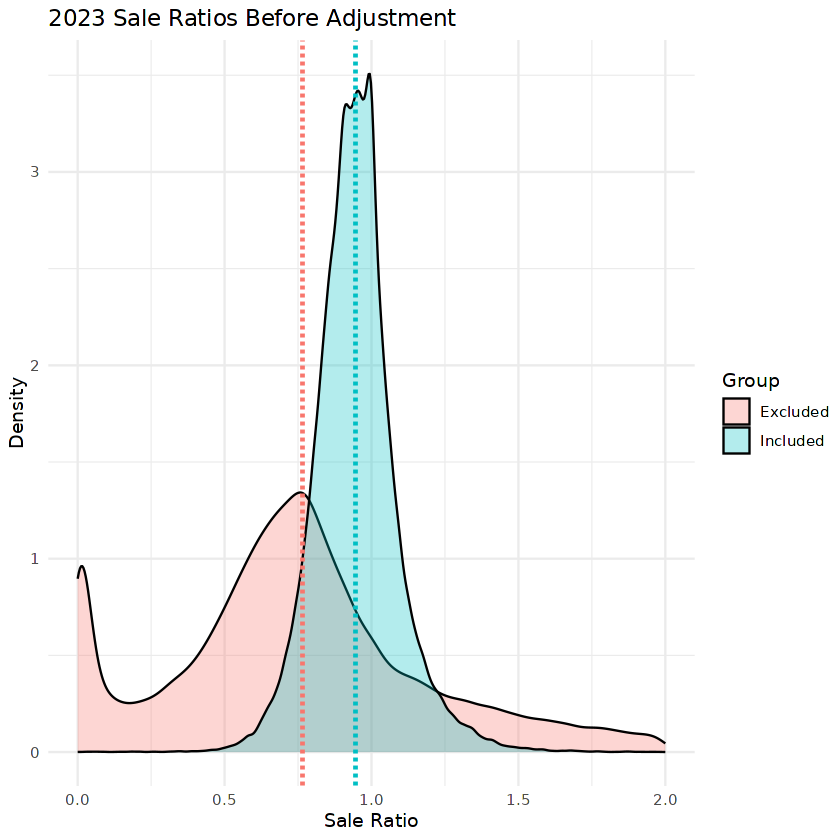

In [28]:
## Plots distributions for 2023 sale ratios before AV adjustment
library(ggplot2)
library(dplyr)

combinedexc23_grouped <- combinedexc23 %>%
  select(PostedSaleRatio) %>%
  mutate(Group = "Excluded")

combinedrat23_grouped <- combinedrat23 %>%
  select(PostedSaleRatio) %>%
  mutate(Group = "Included")

combined_data <- bind_rows(combinedexc23_grouped, combinedrat23_grouped)

medians <- combined_data %>%
  group_by(Group) %>%
  summarize(med = median(PostedSaleRatio, na.rm = TRUE))

ggplot(combined_data, aes(x = PostedSaleRatio, fill = Group)) +
  geom_density(alpha = 0.3) +
  geom_vline(data = medians, aes(xintercept = med, color = Group),
             linetype = "dashed", size = 1, show.legend = FALSE) +
  labs(title = "2023 Sale Ratios Before Adjustment",
       x = "Sale Ratio",
       y = "Density") +
  xlim(0, 2) +
  theme_minimal()



Warning message:
"Removed 15400 rows containing non-finite outside the scale range
(`stat_density()`)."


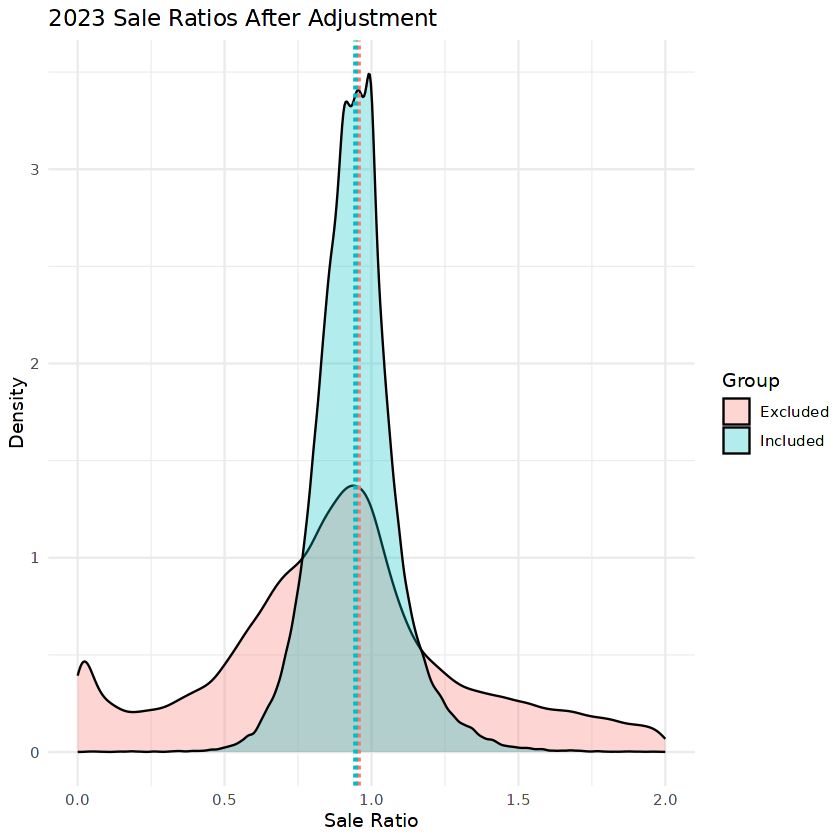

In [29]:
## Plots distributions for 2023 sale ratios after AV adjustment
combinedexc23_grouped <- combinedexc23 %>%
  select(SaleRatio) %>%
  mutate(Group = "Excluded")

combinedrat23_grouped <- combinedrat23 %>%
  select(SaleRatio) %>%
  mutate(Group = "Included")

# Combine datasets
combined_data <- bind_rows(combinedexc23_grouped, combinedrat23_grouped)

# Compute medians for each group
medians <- combined_data %>%
  group_by(Group) %>%
  summarize(med = median(SaleRatio, na.rm = TRUE))

# Plot
ggplot(combined_data, aes(x = SaleRatio, fill = Group)) +
  geom_density(alpha = 0.3) +
  geom_vline(data = medians, aes(xintercept = med, color = Group),
             linetype = "dashed", size = 1, show.legend = FALSE) +
  labs(title = "2023 Sale Ratios After Adjustment",
       x = "Sale Ratio",
       y = "Density") +
  xlim(0, 2) +
  theme_minimal()

Warning message:
"Removed 4849 rows containing non-finite outside the scale range
(`stat_density()`)."


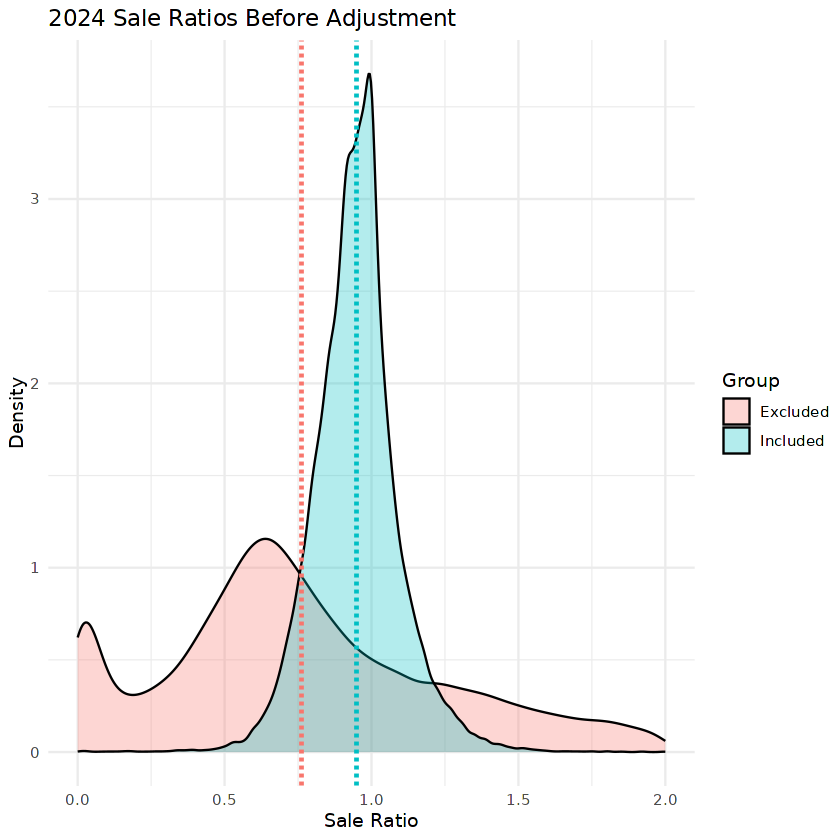

In [30]:
## Plots distributions for 2024 sale ratios before AV adjustment
combinedexc24_grouped <- combinedexc24 %>%
  select(PostedSaleRatio) %>%
  mutate(Group = "Excluded")

combinedrat24_grouped <- combinedrat24 %>%
  select(PostedSaleRatio) %>%
  mutate(Group = "Included")

# Combine datasets
combined_data <- bind_rows(combinedexc24_grouped, combinedrat24_grouped)

# Compute medians for each group
medians <- combined_data %>%
  group_by(Group) %>%
  summarize(med = median(PostedSaleRatio, na.rm = TRUE))

# Plot
ggplot(combined_data, aes(x = PostedSaleRatio, fill = Group)) +
  geom_density(alpha = 0.3) +
  geom_vline(data = medians, aes(xintercept = med, color = Group),
             linetype = "dashed", size = 1, show.legend = FALSE) +
  labs(title = "2024 Sale Ratios Before Adjustment",
       x = "Sale Ratio",
       y = "Density") +
  xlim(0, 2) +
  theme_minimal()

Warning message:
"Removed 7521 rows containing non-finite outside the scale range
(`stat_density()`)."


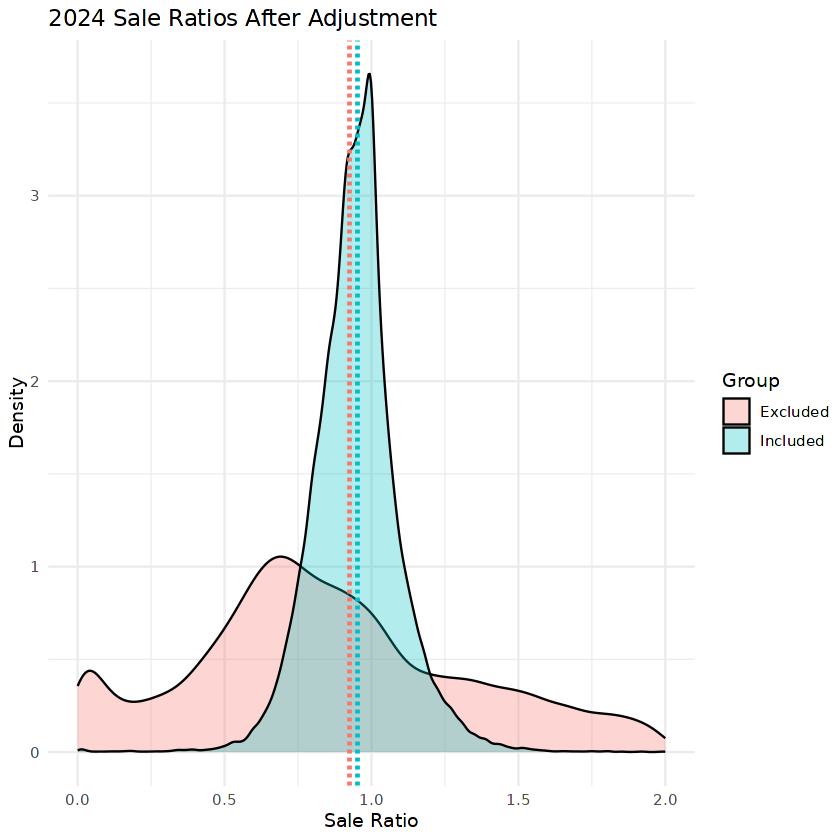

In [31]:
## Plots distributions for 2024 sale ratios after AV adjustment
combinedexc24_grouped <- combinedexc24 %>%
  select(SaleRatio) %>%
  mutate(Group = "Excluded")

combinedrat24_grouped <- combinedrat24 %>%
  select(SaleRatio) %>%
  mutate(Group = "Included")

# Combine datasets
combined_data <- bind_rows(combinedexc24_grouped, combinedrat24_grouped)

# Compute medians for each group
medians <- combined_data %>%
  group_by(Group) %>%
  summarize(med = median(SaleRatio, na.rm = TRUE))

# Plot
ggplot(combined_data, aes(x = SaleRatio, fill = Group)) +
  geom_density(alpha = 0.3) +
  geom_vline(data = medians, aes(xintercept = med, color = Group),
             linetype = "dashed", size = 1, show.legend = FALSE) +
  labs(title = "2024 Sale Ratios After Adjustment",
       x = "Sale Ratio",
       y = "Density") +
  xlim(0, 2) +
  theme_minimal()